In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Defining Convenient Column Names for the dataset
columns =[
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
]

sensor_columns = [
    f"sensor_{i}"
    for i in range(1,22)
]

columns.extend(sensor_columns)

len(columns)

26

### Load Training Data

In [3]:
train_path = "../data/train_FD001.txt"

train_df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None,
    names=columns
)

In [4]:
train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
train_df.shape

(20631, 26)

In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

In [7]:
# How many unique engines are there in the dataset?

train_df["engine_id"].nunique()

100

In [8]:
# What is the first engine's last recorded cycle?
train_df.loc[
    train_df["engine_id"]==1,
    "cycle"
].max()

np.int64(192)

### Inspecting Engine 1

In [9]:
engine_1 = train_df[
    train_df["engine_id"]==1
]

engine_1.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [10]:
engine_1.tail()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,520.08,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649


In [11]:
engine_1.shape

(192, 26)

In [12]:
engine_1["cycle"].min(),engine_1["cycle"].max()

(np.int64(1), np.int64(192))

### Looking for useful sensors through visualization

In [13]:
sensor_columns

['sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [14]:
engines_to_plot = [1,2,3,4]

engine_lifetimes = (
    train_df.groupby("engine_id")["cycle"].max()
)

engine_lifetimes.loc[engines_to_plot]

engine_id
1    192
2    287
3    179
4    189
Name: cycle, dtype: int64

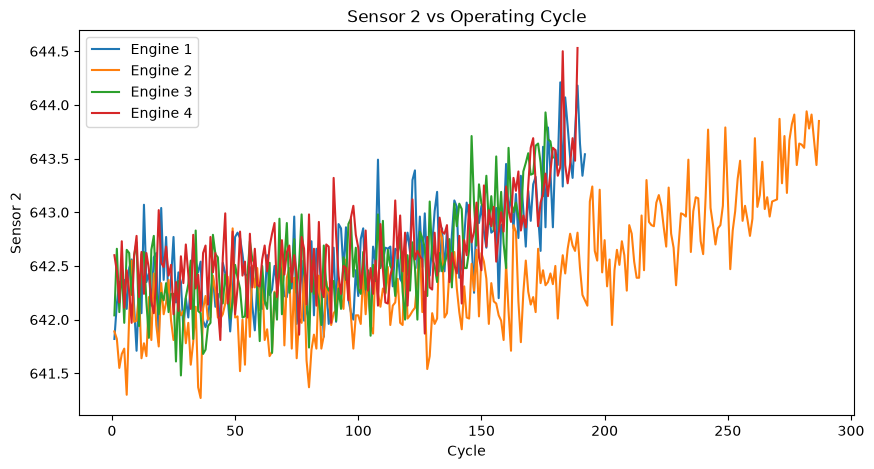

In [15]:
plt.figure(figsize=(10,5))

for engine_id in engines_to_plot:
    engine_data= train_df[
        train_df["engine_id"] == engine_id
    ]

    plt.plot(
        engine_data["cycle"],
        engine_data["sensor_2"],
        label=f"Engine {engine_id}"
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 vs Operating Cycle")
plt.legend()
plt.show()

### Comparing Several Sensors

In [16]:
def plot_sensor(sensor_name,engines):
    plt.figure(figsize=(10,5))

    for engine_id in engines:
        engine_data = train_df[
            train_df["engine_id"] == engine_id
        ]

        plt.plot(
            engine_data["cycle"],
            engine_data[sensor_name],
            label=f"Engine {engine_id}"
        )

    plt.xlabel("Cycle")
    plt.ylabel(sensor_name)
    plt.title(f"{sensor_name} vs Operating Cycle")
    plt.legend()
    plt.show()

### Plotting all sensors using subplots

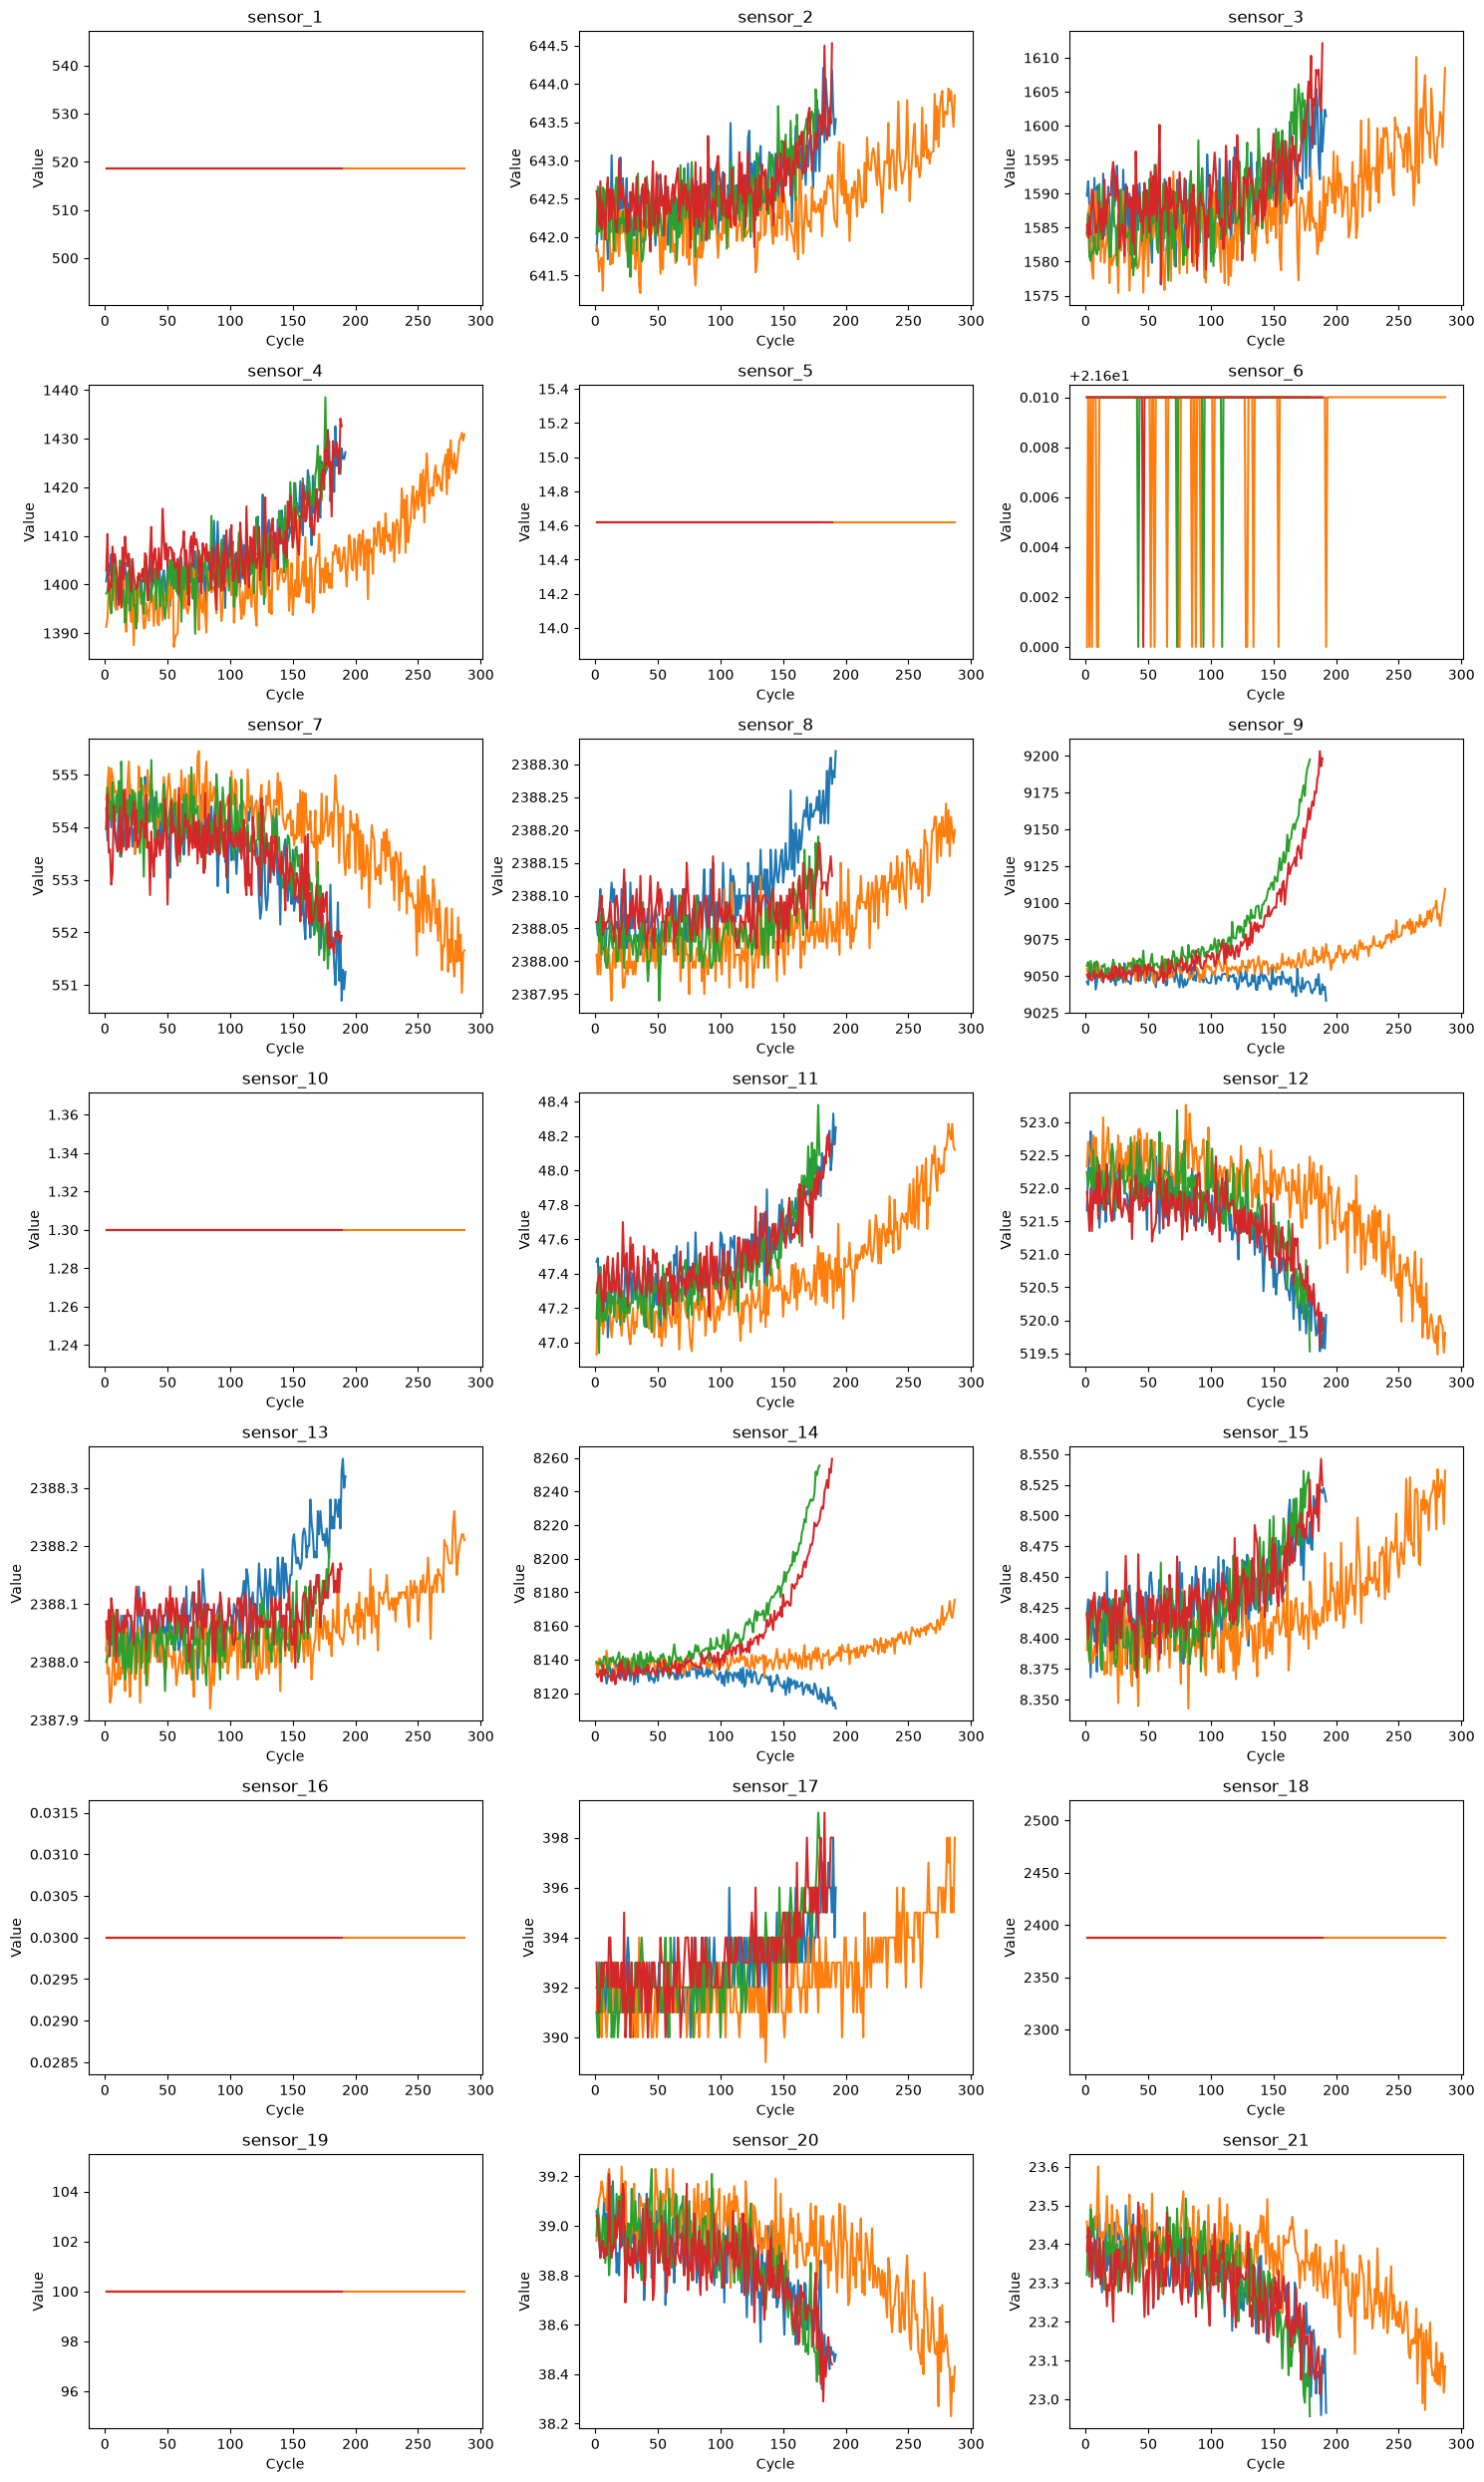

In [17]:
fig, axes = plt.subplots(
    7, 3, figsize=(15,25)
)

for i, sensor in enumerate(sensor_columns):
    ax = axes[i // 3, i % 3]

    for engine_id in engines_to_plot:
        engine_data = train_df[
            train_df["engine_id"] == engine_id
        ]

        ax.plot(
            engine_data["cycle"],
            engine_data[sensor],
            label=f"E{engine_id}"
        )

    ax.set_title(sensor)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

### Engine Lifetime Distribution

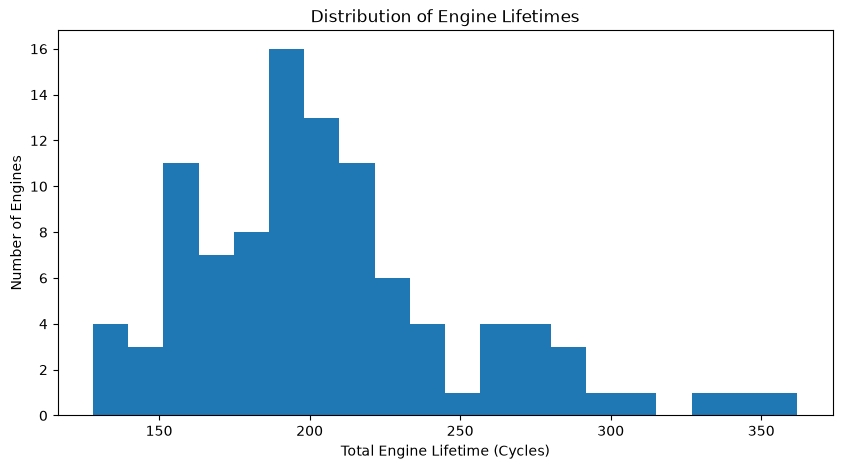

In [18]:
plt.figure(figsize=(10,5))

plt.hist(
    engine_lifetimes,
    bins=20
)

plt.xlabel("Total Engine Lifetime (Cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")
plt.show()

### Plotting One Engine with several Sensors

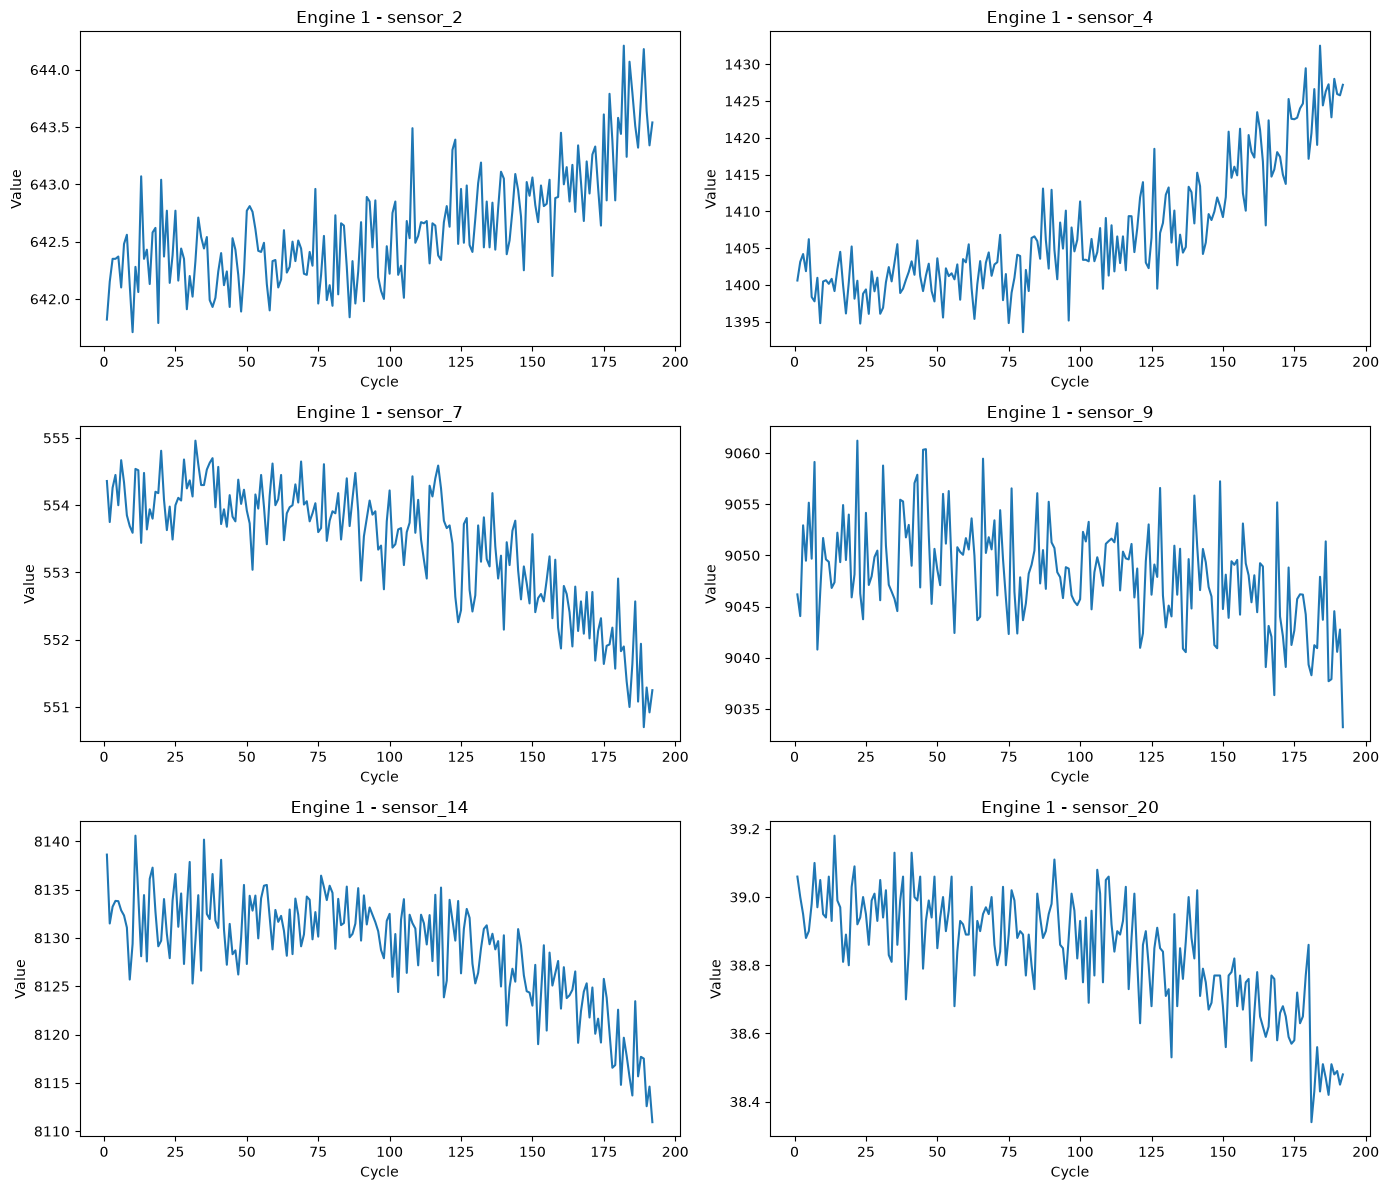

In [19]:
engine_1 = train_df[train_df["engine_id"]==1]

selected_sensors = [
    "sensor_2",
    "sensor_4",
    "sensor_7",
    "sensor_9",
    "sensor_14",
    "sensor_20"
]

fig, axes =  plt.subplots(
    3, 2, figsize=(14,12)
)

for ax, sensor in zip(axes.flat, selected_sensors):

    ax.plot(
        engine_1["cycle"],
        engine_1[sensor]
    )

    ax.set_title(f"Engine 1 - {sensor}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

### Operational Settings Analysis

In [20]:
settings = ["setting_1", "setting_2", "setting_3"]

train_df[settings].describe()

,setting_1,setting_2,setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


In [21]:
# How may unique values each setting has 
for col in settings:
    print(f"{col}: {train_df[col].nunique()} unique values")

setting_1: 158 unique values
setting_2: 13 unique values
setting_3: 1 unique values


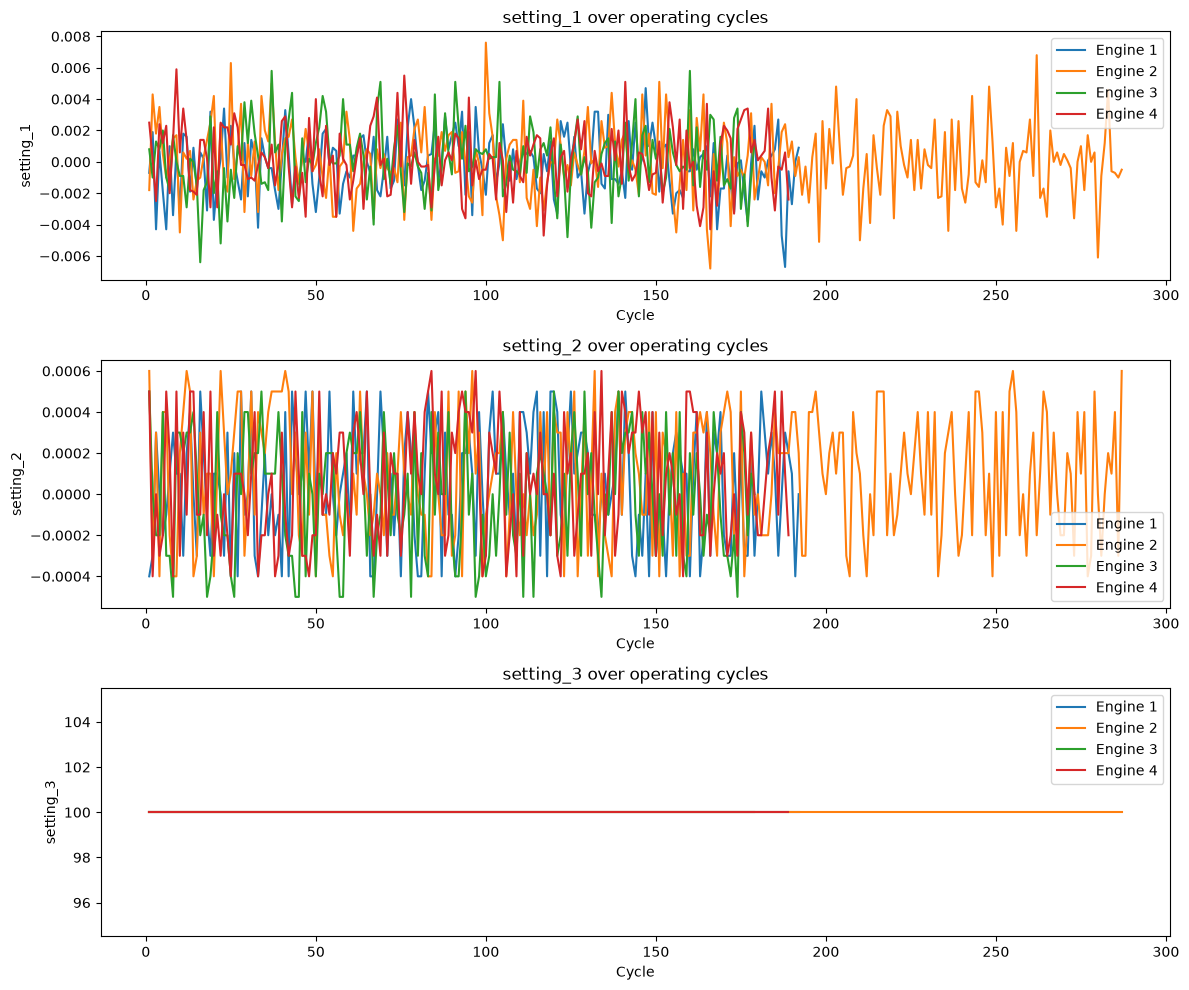

In [22]:
# Visualizing the settings

fig, axes = plt.subplots(3, 1, figsize=(12,10))

for ax, setting in zip(axes, settings):
    for engine in [1, 2, 3, 4]:
        engine_data= train_df[train_df["engine_id"]==engine]
        ax.plot(
            engine_data["cycle"],
            engine_data[setting],
            label=f"Engine {engine}"
        )
    ax.set_title(f"{setting} over operating cycles")
    ax.set_xlabel("Cycle")
    ax.set_ylabel(setting)
    ax.legend()

plt.tight_layout()
plt.show()

In [23]:
# Correlation between Settings and Sensors
correlation = train_df[settings + [f"sensor_{i}" for i in range(1, 22)]].corr()

correlation.loc[settings, [f"sensor_{i}" for i in range(1, 22)]]

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
setting_1,NaN,0.009030,-0.005651,0.009544,NaN,-0.001340,-0.009437,-0.000427,-0.004279,NaN,...,-0.001491,0.002318,-0.004469,0.007652,NaN,0.002599,NaN,NaN,-0.005713,-0.014559
setting_2,NaN,0.007266,0.009068,0.014673,NaN,0.014355,-0.016678,0.013285,-0.005425,NaN,...,-0.010923,0.018156,-0.006310,0.014156,NaN,0.012280,NaN,NaN,-0.010554,-0.007846
setting_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Operating Settings — Key Findings

- `setting_1` contains 158 unique values and fluctuates around zero.
- `setting_2` contains 13 unique values and behaves as a discrete operating condition.
- `setting_3` has only one unique value (100) across the entire FD001 training dataset.
- Since `setting_3` has zero variance, its correlation with other variables is undefined and appears as NaN.
- `setting_3` provides no variation for the model and will therefore be excluded from the predictive feature set.
- The observed Pearson correlations between `setting_1`/`setting_2` and the displayed sensors are generally close to zero.
- Correlation analysis is exploratory and will not be used as the sole criterion for feature selection.
- Operating settings must be distinguished from degradation signals because changes in sensor values can potentially be influenced by operating conditions.

## RUL Target Construction 

### Step 1: Find Maximum Cycle for Each Engine

In [24]:
max_cycles = (
    train_df.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)

max_cycles.head(10)

,engine_id,cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
5,6,188
6,7,259
7,8,150
8,9,201
9,10,222


In [25]:
max_cycles = max_cycles.rename(columns={"cycle": "max_cycle"})

max_cycles.head(10)

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
5,6,188
6,7,259
7,8,150
8,9,201
9,10,222


In [26]:
print("Number of Engines:", max_cycles["engine_id"].nunique())
print("Number of Rows:", len(max_cycles))

Number of Engines: 100
Number of Rows: 100


In [27]:
max_cycles["max_cycle"].describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: max_cycle, dtype: float64

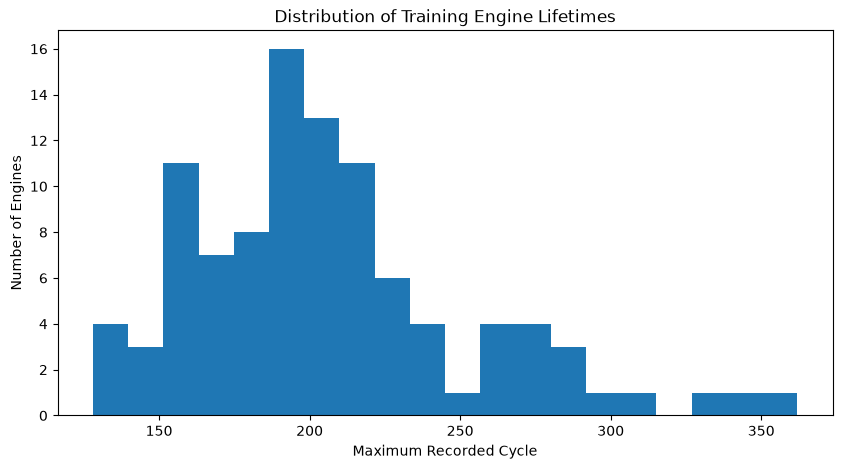

In [28]:
plt.figure(figsize=(10, 5))

plt.hist(max_cycles["max_cycle"], bins=20)

plt.xlabel("Maximum Recorded Cycle")
plt.ylabel("Number of Engines")
plt.title("Distribution of Training Engine Lifetimes")

plt.show()

### Step 2: Add Each Engine's Maximum Cycle

In [29]:
train_df = train_df.merge(
    max_cycles,
    on="engine_id",
    how="left"
)

train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


In [30]:
print("Rows:", len(train_df))
print("Missing max_cycle:", train_df["max_cycle"].isna().sum())

Rows: 20631
Missing max_cycle: 0


In [31]:
train_df[train_df["engine_id"]==1][
    ["engine_id", "cycle", "max_cycle"]
].tail()

,engine_id,cycle,max_cycle
187,1,188,192
188,1,189,192
189,1,190,192
190,1,191,192
191,1,192,192


## Calculating RUL

In [32]:
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]

In [33]:
train_df[
    train_df["engine_id"]==1
][["engine_id", "cycle", "max_cycle", "RUL"]].head()

,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


In [34]:
train_df[
    train_df["engine_id"]==1
][["engine_id", "cycle", "max_cycle", "RUL"]].tail()

,engine_id,cycle,max_cycle,RUL
187,1,188,192,4
188,1,189,192,3
189,1,190,192,2
190,1,191,192,1
191,1,192,192,0


In [35]:
print("Minimum RUL:", train_df["RUL"].min())
print("Maximum RUL:", train_df["RUL"].max())
print("Negative RUL values:", (train_df["RUL"]<0).sum())

Minimum RUL: 0
Maximum RUL: 361
Negative RUL values: 0


In [36]:
final_cycles = train_df.loc[
    train_df["cycle"] == train_df["max_cycle"],
    ["engine_id", "cycle", "max_cycle", "RUL"]
]

final_cycles.head(10)

,engine_id,cycle,max_cycle,RUL
191,1,192,192,0
478,2,287,287,0
657,3,179,179,0
846,4,189,189,0
1115,5,269,269,0
1303,6,188,188,0
1562,7,259,259,0
1712,8,150,150,0
1913,9,201,201,0
2135,10,222,222,0


In [37]:
print("Final-cycle rows with RUL !=0:",
      (final_cycles["RUL"] !=0).sum())

Final-cycle rows with RUL !=0: 0


In [38]:
train_sorted = train_df.sort_values(
    ["engine_id", "cycle"]
)

rul_step=(
    train_sorted.groupby("engine_id")["RUL"]
    .diff()
    .dropna()
)

print("Incorrect RUL steps:", (rul_step != -1).sum())

Incorrect RUL steps: 0


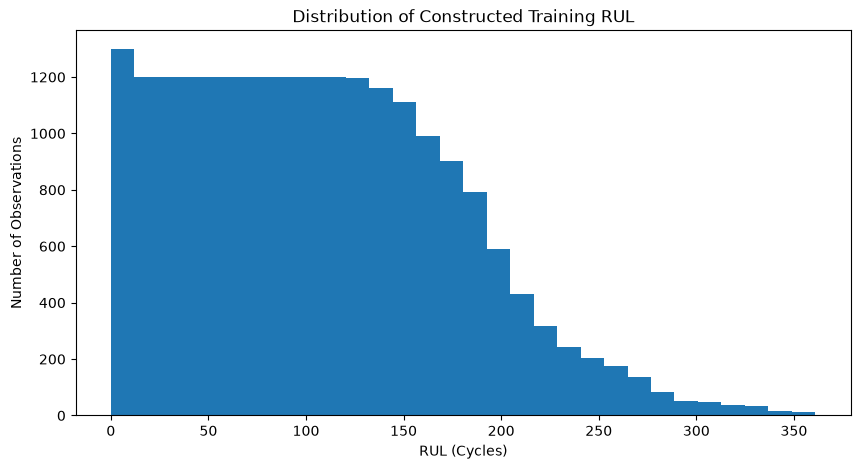

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(train_df["RUL"], bins=30)

plt.xlabel("RUL (Cycles)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Constructed Training RUL")

plt.show()

In [40]:
# Final RUL target validation
assert train_df["RUL"].min() == 0
assert train_df["RUL"].max() == 361
assert (train_df["RUL"]<0).sum() == 0
assert (final_cycles["RUL"] !=0).sum() == 0
assert (rul_step !=-1).sum() == 0

print("✅ All RUL validation checks passed!")

✅ All RUL validation checks passed!
